In [34]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

from temgym_core.gaussian import InterpolatedFields3D, InterpolatedSample2D
import jax.numpy as jnp
from temgym_core.utils import energy2wavelength
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, c, e
import jax
jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [35]:
def rotation_matrix_x(theta):
    c = jnp.cos(theta)
    s = jnp.sin(theta)
    return jnp.array([
        [1.0, 0.0, 0.0],
        [0.0,   c,  -s],
        [0.0,   s,   c],
    ])

def make_test_cube_fields_tilted(
    tilt_x,             # tilt angle [rad] about x-axis
    Nx=128, Ny=128, Nz=128,
    Lx=100e-9, Ly=100e-9, Lz=100e-9,
    V0=10.0,            # mean inner potential [V]
    B0=1.0,             # toy internal B [Tesla]
):
    """
    Build a uniform MIP + uniform magnetisation cube, tilted by tilt_x
    around the lab x-axis.

    Returns:
        fields: (Nx, Ny, Nz, 2) with channels [V, A_z_lab]
        x_coords, y_coords, z_coords: lab coordinates
    """
    # --- lab coordinates ---
    x_coords = jnp.linspace(-Lx / 2, Lx / 2, Nx)
    y_coords = jnp.linspace(-Ly / 2, Ly / 2, Ny)
    z_coords = jnp.linspace(-Lz / 2, Lz / 2, Nz)

    Y_lab, X_lab, Z_lab = jnp.meshgrid(y_coords, x_coords, z_coords, indexing="ij")

    # --- rotation: object -> lab ---
    R = rotation_matrix_x(tilt_x)
    R_T = R.T

    # Map lab coordinates to object coordinates: r_obj = R^T r_lab
    X_obj = R_T[0, 0] * X_lab + R_T[0, 1] * Y_lab + R_T[0, 2] * Z_lab
    Y_obj = R_T[1, 0] * X_lab + R_T[1, 1] * Y_lab + R_T[1, 2] * Z_lab
    Z_obj = R_T[2, 0] * X_lab + R_T[2, 1] * Y_lab + R_T[2, 2] * Z_lab

    # --- cube mask in object coordinates ---
    mask = (
        (jnp.abs(X_obj) <= Lx / 4) &
        (jnp.abs(Y_obj) <= Ly / 4) &
        (jnp.abs(Z_obj) <= Lz / 4)
    )

    # --- MIP: uniform V0 inside cube ---
    V = V0 * mask

    # --- Magnetic gauge in object frame ---
    # A_obj = (0, 0, B0 * x_obj)
    A_z_obj = B0 * X_obj * mask

    # Transform A to lab frame: A_lab = R @ A_obj
    # Since A_obj = (0,0,A_z_obj), we have A_z_lab = R[2,2] * A_z_obj
    A_z_lab = R[2, 2] * A_z_obj

    fields = jnp.stack([V, A_z_lab], axis=-1)  # (Nx, Ny, Nz, 2)

    return fields, x_coords, y_coords, z_coords


def project_phase_along_z(fields, z_coords, C_E, e_over_hbar):
    V = fields[..., 0]    # (Nx, Ny, Nz)
    A_z = fields[..., 1]  # (Nx, Ny, Nz)

    dz = z_coords[1] - z_coords[0]
    g = C_E * V + e_over_hbar * A_z   # generator per unit length

    phi = jnp.sum(g, axis=-1) * dz    # integrate over z → shape (Nx, Ny)
    return phi


def interaction_constant_CE(V):
    """
    Electrostatic phase interaction constant C_E [rad / (V·m)]
    as used in electron holography.
    """
    gamma = 1.0 + V / (m_e * c**2 / e)
    lam = energy2wavelength(V)

    return gamma * m_e * e * lam / (2 * jnp.pi * hbar**2)


def e_over_hbar():
    """
    Return e/ħ in SI units: rad / (T·m)
    Typically used as the magnetic prefactor in the A·dl integral.
    """
    e   = 1.602176634e-19     # Coulomb
    hbar = 1.054571817e-34    # J·s
    return e / hbar

In [36]:
tilt_0 = jnp.deg2rad(0)  # 0 degrees
tilt_45 = jnp.deg2rad(45)  # 45 degrees
tilt_180 = jnp.deg2rad(180)  # 180 degrees

fields_0, x_coords_0, y_coords_0, z_coords_0 = make_test_cube_fields_tilted(
    tilt_x=tilt_0,
    V0=10.0,
    B0=1.0,
)
cube_0 = InterpolatedFields3D.from_array(fields_0, x_coords_0, y_coords_0, z_coords_0)

fields_45, x_coords_45, y_coords_45, z_coords_45 = make_test_cube_fields_tilted(
    tilt_x=tilt_45,
    V0=10.0,
    B0=1.0,
)
cube_45 = InterpolatedFields3D.from_array(fields_45, x_coords_45, y_coords_45, z_coords_45)

fields_180, x_coords_180, y_coords_180, z_coords_180 = make_test_cube_fields_tilted(
    tilt_x=tilt_180,
    V0=10.0,
    B0=1.0,
)
cube_180 = InterpolatedFields3D.from_array(fields_180, x_coords_180, y_coords_180, z_coords_180)

In [37]:
C_E = interaction_constant_CE(100e3)
e_over_hbar = e_over_hbar()
phi0 = project_phase_along_z(fields_0, z_coords_0, C_E, e_over_hbar)
phi45 = project_phase_along_z(fields_45, z_coords_45, C_E, e_over_hbar)
phi180 = project_phase_along_z(fields_180, z_coords_180, C_E, e_over_hbar)
sample_2d_0 = jnp.exp(1j * phi0)
sample_2d_45 = jnp.exp(1j * phi45)
sample_2d_180 = jnp.exp(1j * phi180)


Text(0.5, 0.98, 'Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')

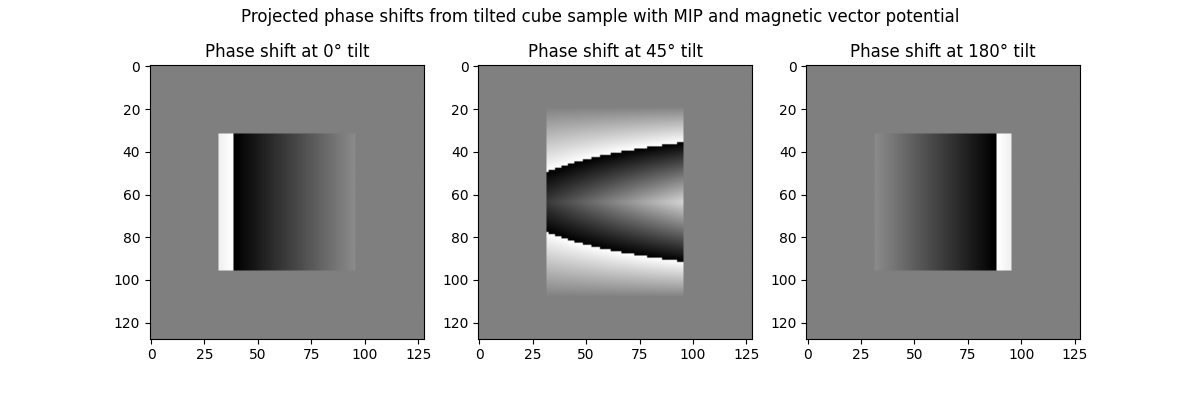

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(jnp.angle(sample_2d_0), cmap='gray')
axs[0].set_title('Phase shift at 0° tilt')
axs[1].imshow(jnp.angle(sample_2d_45), cmap='gray')
axs[1].set_title('Phase shift at 45° tilt')
axs[2].imshow(jnp.angle(sample_2d_180), cmap='gray')
axs[2].set_title('Phase shift at 180° tilt')
fig.suptitle('Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')

In [39]:
import numpy as np
import plotly.graph_objects as go

def rotation_matrix_x(theta):
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0,   c,  -s],
        [0.0,   s,   c],
    ])

def make_tilted_cube_vectors(tilt_x_deg=30, L=1.0, n=7, B0=1.0):
    """
    Build a tilted cube with a uniform magnetisation vector field.

    tilt_x_deg : tilt angle about the lab x-axis (degrees)
    L          : cube edge length in object frame
    n          : number of sample points per axis for vectors
    B0         : magnitude of magnetisation

    Returns:
        x0, y0, z0 : positions of cone tails (lab frame)
        u, v, w    : vector components (lab frame)
        R          : rotation matrix (object -> lab)
    """
    tilt_x = np.deg2rad(tilt_x_deg)
    R = rotation_matrix_x(tilt_x)
    R_T = R.T

    # Lab coordinates (visualisation box). Make it at least as large as the cube.
    box = L  # you can increase this if you want margin
    x = np.linspace(-box/2, box/2, n)
    y = np.linspace(-box/2, box/2, n)
    z = np.linspace(-box/2, box/2, n)
    X_lab, Y_lab, Z_lab = np.meshgrid(x, y, z, indexing="ij")

    # Map lab -> object coords: r_obj = R^T r_lab
    X_obj = R_T[0, 0] * X_lab + R_T[0, 1] * Y_lab + R_T[0, 2] * Z_lab
    Y_obj = R_T[1, 0] * X_lab + R_T[1, 1] * Y_lab + R_T[1, 2] * Z_lab
    Z_obj = R_T[2, 0] * X_lab + R_T[2, 1] * Y_lab + R_T[2, 2] * Z_lab

    # Cube mask in object frame
    mask = (
        (np.abs(X_obj) <= L/2) &
        (np.abs(Y_obj) <= L/2) &
        (np.abs(Z_obj) <= L/2)
    )

    # Object-frame magnetisation (e.g. pointing +y_obj)
    B_obj = np.array([0.0, B0, 0.0])   # uniform

    # Rotate B to lab frame: B_lab = R @ B_obj
    B_lab = R @ B_obj  # same vector everywhere

    # Extract points inside cube
    idx = np.where(mask)
    x0 = X_lab[idx]
    y0 = Y_lab[idx]
    z0 = Z_lab[idx]

    # Optionally subsample to avoid too many arrows
    max_arrows = 100
    if x0.size > max_arrows:
        choice = np.random.choice(x0.size, size=max_arrows, replace=False)
        x0 = x0[choice]
        y0 = y0[choice]
        z0 = z0[choice]

    # Same vector at each position (uniform magnetisation)
    u = np.full_like(x0, B_lab[0])
    v = np.full_like(y0, B_lab[1])
    w = np.full_like(z0, B_lab[2])

    return x0, y0, z0, u, v, w, R

# --- build tilted cube vectors ---
x0, y0, z0, u, v, w, R = make_tilted_cube_vectors(
    tilt_x_deg=40,  # tilt around x-axis
    L=1.0,
    n=64,
    B0=1.0,
)

# --- create Plotly figure ---
fig = go.Figure()

# Vectors (magnetisation)
fig.add_trace(go.Cone(
    x=x0, y=y0, z=z0,
    u=u, v=v, w=w,
    sizemode="scaled",
    sizeref=1,
    showscale=False,
    anchor="tail",
))

fig.update_layout(
    scene=dict(
        xaxis_title="x (lab)",
        yaxis_title="y (lab)",
        zaxis_title="z (lab)",
        aspectmode="data",
    ),
    title="Tilted Cube with Uniform Magnetisation (lab frame)",
)

fig.show()
